# Day 5 - Regularization / Normalization

> **Goal:** Understand why models overfit, how regularization controls model complexity, and why normalization layers are important in modern deep learning.

## Learning Map

1. Overfitting / Underfitting — D2L §4.4
2. Weight Decay — D2L §4.5
3. Dropout — D2L §4.6
4. Batch Normalization — D2L BatchNorm section
5. LayerNorm — Transformer / LLM connection
6. RMSNorm — LLM connection
7. BatchNorm vs LayerNorm vs RMSNorm
8. Day 5 Summary

# 1. Overfitting / Underfitting

> Source: D2L §4.4

In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [3]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.8158],
         [-0.5591]]),
 tensor([[ 1.0000e+00,  8.1583e-01,  3.3279e-01,  9.0500e-02,  1.8458e-02,
           3.0118e-03,  4.0952e-04,  4.7728e-05,  4.8673e-06,  4.4121e-07,
           3.5995e-08,  2.6696e-09,  1.8150e-10,  1.1390e-11,  6.6375e-13,
           3.6100e-14,  1.8407e-15,  8.8337e-17,  4.0038e-18,  1.7192e-19],
         [ 1.0000e+00, -5.5905e-01,  1.5627e-01, -2.9121e-02,  4.0700e-03,
          -4.5507e-04,  4.2402e-05, -3.3864e-06,  2.3665e-07, -1.4700e-08,
           8.2179e-10, -4.1766e-11,  1.9458e-12, -8.3676e-14,  3.3414e-15,
          -1.2453e-16,  4.3513e-18, -1.4309e-19,  4.4443e-21, -1.3077e-22]]),
 tensor([5.2718, 3.6019]))

In [4]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [10]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):

    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]

    # 不设置 bias，因为多项式第一个特征已经是常数 1
    net = nn.Sequential(
        nn.Linear(input_shape, 1, bias=False)
    )

    batch_size = min(10, train_labels.shape[0])

    train_iter = d2l.load_array(
        (train_features, train_labels.reshape(-1, 1)),
        batch_size
    )

    test_iter = d2l.load_array(
        (test_features, test_labels.reshape(-1, 1)),
        batch_size,
        is_train=False
    )

    trainer = torch.optim.SGD(
        net.parameters(),
        lr=0.01
    )

    animator = d2l.Animator(
        xlabel='epoch',
        ylabel='loss',
        yscale='log',
        xlim=[1, num_epochs],
        ylim=[1e-3, 1e2],
        legend=['train', 'test']
    )

    for epoch in range(num_epochs):

        # ---- one training epoch ----
        for X, y in train_iter:
            trainer.zero_grad()

            y_hat = net(X)
            l = loss(y_hat, y)

            l.mean().backward()
            trainer.step()

        # ---- evaluation ----
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(
                epoch + 1,
                (
                    evaluate_loss(net, train_iter, loss),
                    evaluate_loss(net, test_iter, loss)
                )
            )

    print('weight:', net[0].weight.data.numpy())

weight: [[ 5.0075216  1.1847564 -3.3948035  5.598881 ]]


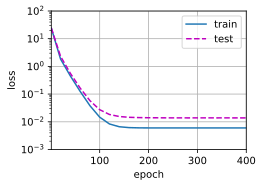

In [11]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.716049  4.6314163]]


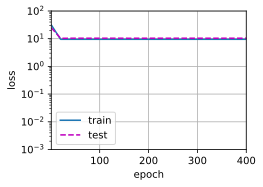

In [12]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.9623027   1.2563747  -3.1541555   5.237307   -0.6093289   1.1395112
  -0.20470369  0.20932072 -0.03817529 -0.22371234 -0.07958636 -0.11072433
   0.02905889 -0.07091143 -0.04814296  0.15919204  0.17836766 -0.16664833
   0.08242583  0.04960435]]


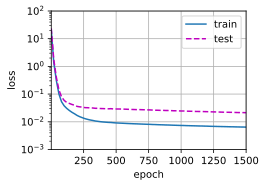

In [13]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

# 2. Weight Decay

> Source: D2L §4.5  
> Connection: Day 4 AdamW

In [14]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [15]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [16]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [20]:
def l2_penalty(w):
    return torch.sum(w.pow(2))/2

In [21]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.45942211151123


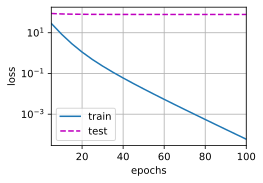

In [22]:
train(lambd=0)

w的L2范数是： 0.36394792795181274


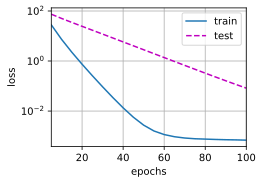

In [23]:
train(lambd=3)

In [24]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 13.370821952819824


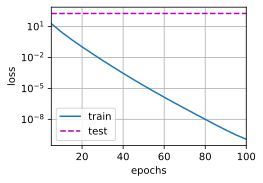

In [25]:
train_concise(0)

w的L2范数： 0.4046887159347534


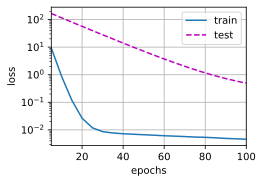

In [26]:
train_concise(3)

w的L2范数： 0.09843101352453232


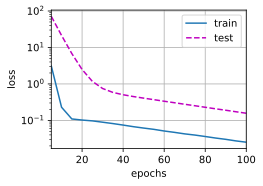

In [27]:
train_concise(10)

w的L2范数： 0.016234876587986946


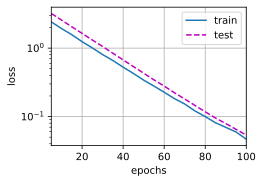

In [30]:
train_concise(100)

# 3. Dropout

> Source: D2L §4.6

In [31]:
import torch
from torch import nn
from d2l import torch as d2l


def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 在本情况中，所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 在本情况中，所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [32]:
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  0.,  0.,  0., 10., 12., 14.],
        [ 0., 18.,  0.,  0., 24., 26., 28.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [33]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

In [48]:
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out


net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

In [49]:
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)

In [50]:
import matplotlib.pyplot as plt

train_losses = []
train_accs = []
test_accs = []

def evaluate_accuracy(net, data_iter):
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            pred = y_hat.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total


for epoch in range(num_epochs):
    # =========================
    # 1. Training
    # =========================
    net.train()

    total_loss = 0
    total = 0

    for X, y in train_iter:
        trainer.zero_grad()

        y_hat = net(X)
        l = loss(y_hat, y)

        l.mean().backward()
        trainer.step()

        total_loss += l.sum().item()
        total += y.numel()

    train_loss = total_loss / total

    # =========================
    # 2. Evaluation
    # Dropout OFF for BOTH train/test
    # =========================
    train_acc = evaluate_accuracy(net, train_iter)
    test_acc = evaluate_accuracy(net, test_iter)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"epoch {epoch + 1}: "
        f"loss={train_loss:.4f}, "
        f"train acc={train_acc:.4f}, "
        f"test acc={test_acc:.4f}"
    )

epoch 1: loss=0.9034, train acc=0.8211, test acc=0.8073
epoch 2: loss=0.5306, train acc=0.7237, test acc=0.7094
epoch 3: loss=0.4641, train acc=0.8271, test acc=0.8119
epoch 4: loss=0.4243, train acc=0.8457, test acc=0.8291
epoch 5: loss=0.4016, train acc=0.8670, test acc=0.8510
epoch 6: loss=0.3815, train acc=0.8787, test acc=0.8626
epoch 7: loss=0.3691, train acc=0.8592, test acc=0.8421
epoch 8: loss=0.3570, train acc=0.8868, test acc=0.8671
epoch 9: loss=0.3406, train acc=0.8723, test acc=0.8527
epoch 10: loss=0.3363, train acc=0.8914, test acc=0.8698


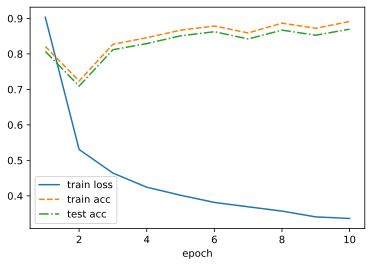

In [51]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))

plt.plot(epochs, train_losses, label='train loss')
plt.plot(epochs, train_accs, '--', label='train acc')
plt.plot(epochs, test_accs, '-.', label='test acc')

plt.xlabel('epoch')
plt.legend()
plt.show()

In [40]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,256),
    nn.ReLU(),
    nn.Dropout(dropout1),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Dropout(dropout2),
)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std = 0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
)

# 4. Batch Normalization

> Source: D2L BatchNorm section

In [2]:
import torch
from torch import nn

bn = nn.BatchNorm1d(4)

# Example shape: batch_size x features
x = torch.randn(8, 4)

y = bn(x)

print("input shape :", x.shape)
print("output shape:", y.shape)


input shape : torch.Size([8, 4])
output shape: torch.Size([8, 4])


# 5. LayerNorm

> Transformer / LLM connection

In [3]:
from torch import nn
import torch

# batch x sequence_length x hidden_dim
x = torch.randn(2, 5, 8)

ln = nn.LayerNorm(8)
y = ln(x)

print("input shape :", x.shape)
print("output shape:", y.shape)

# LayerNorm normalizes the last dimension (hidden_dim=8)
# independently for each token representation.


input shape : torch.Size([2, 5, 8])
output shape: torch.Size([2, 5, 8])


# 6. RMSNorm

> LLM connection

# 7. BatchNorm vs LayerNorm vs RMSNorm

Fill in / revise this table after studying.

| Method | Normalizes Across | Depends on Batch? | Common Context | Key Idea |
|---|---|---:|---|---|
| BatchNorm | Batch statistics for each feature/channel | Yes | CNNs | Stabilize feature distributions using batch statistics |
| LayerNorm | Features within each sample/token | No | Transformers / LLMs | Normalize each hidden representation independently |
| RMSNorm | RMS scale of features within each sample/token | No | Modern LLMs | Simpler scale normalization |

## Important Distinction

**Regularization** mainly targets generalization / model complexity.

Examples:
- Weight decay
- Dropout

**Normalization** mainly controls activation / representation scale and training behavior.

Examples:
- BatchNorm
- LayerNorm
- RMSNorm


# 8. Day 5 Summary

- **Underfitting vs Overfitting**  
  Underfitting: the model cannot fit the training data well.  
  Overfitting: training performance is good, but validation/test performance is much worse.

- **Why training loss alone is not enough**  
  Low training loss may only mean the model memorized the training data.  
  Generalization must be judged using validation/test performance.

- **What Weight Decay does**  
  Weight Decay limits parameter magnitude and continuously pulls weights toward zero.  
  It reduces excessive model freedom and can improve generalization.

- **Why Dropout helps generalization**  
  Dropout randomly removes some activations during training.  
  This prevents the model from relying too heavily on specific neurons or paths.

- **Regularization vs Normalization**  
  Regularization mainly targets overfitting and generalization.  
  Examples: Weight Decay, Dropout.

  Normalization mainly controls activation scale and training stability.  
  Examples: BatchNorm, LayerNorm, RMSNorm.

- **BatchNorm**  
  Normalizes the same feature/channel using statistics across the batch.  
  Common in CNNs.

- **LayerNorm**  
  Normalizes features within each sample/token independently.  
  Common in Transformers.

- **RMSNorm**  
  Similar to LayerNorm, but does not subtract the mean.  
  It mainly controls the RMS magnitude of hidden representations and is common in modern LLMs.

---

## Connection to Previous Days

`forward -> loss -> backward -> optimizer -> parameter update`

Day 5 adds two new concerns:

`Generalization -> Regularization`

`Stable activations -> Normalization`

---

## One-sentence takeaway

> Day 5 is about controlling both **model complexity** and **activation scale** so that the model trains stably and generalizes well.